In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' ## To keep only critical logs
import time

import matplotlib.pyplot as plt
import numpy as np
import PIL
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import layers, models, callbacks, Input

# Check if GPUs are available
gpus = tf.config.list_physical_devices('GPU')

if gpus:
    print(f"Using Device: GPU ({len(gpus)} available)")
    # Optional: Display the specific name of the GPU
    for gpu in gpus:
        print(f"  - {gpu.name}")
else:
    print("Using Device: CPU")

E0000 00:00:1776144853.854771      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776144853.915874      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776144854.433981      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776144854.434028      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776144854.434034      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776144854.434038      55 computation_placer.cc:177] computation placer already registered. Please check linka

Using Device: GPU (2 available)
  - /physical_device:GPU:0
  - /physical_device:GPU:1


### Dataset Pipeline

In [2]:
# Set up the dataset paths and labels
data_path = '/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training'
classes = sorted(os.listdir(data_path))
class_to_idx = {cls_name: i for i, cls_name in enumerate(classes)}
# Build the list of file paths and labels
file_paths = []
labels = []

for cls_name in classes:
    cls_path = os.path.join(data_path, cls_name)
    for img_name in os.listdir(cls_path):
        file_paths.append(os.path.join(cls_path, img_name))
        labels.append(class_to_idx[cls_name])

# Basic preprocessing (except augmentations)
def process_path(file_path, label):
    """
    Read the image from the path as uint8 tensor and resize it to 224, 224 and cast it to float32
    """
    img = tf.io.read_file(file_path)
    img = tf.image.decode_jpeg(img, channels=3)# Decode jpeg/png to a uint8 tensor
    # Resize (equivalent to transforms.Resize)
    img = tf.image.resize(img, [224, 224])
    img = tf.cast(img, tf.float32) / 255.0 # Normalize to [0, 1] (equivalent to transforms.ToTensor)
    return img, label

## Define the dataset
dataset = tf.data.Dataset.from_tensor_slices((file_paths, labels))


## Split dataset into training and val as 80% for train and 20% for val
total_samples = len(file_paths)
train_size = int(0.8 * total_samples)
val_size = total_samples - train_size
full_dataset = dataset.shuffle(total_samples, reshuffle_each_iteration=False)
train_ds = full_dataset.take(train_size)
val_ds = full_dataset.skip(train_size)


I0000 00:00:1776144881.305503      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1776144881.311806      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


### Augmentation

Creating an augment function separately since we want validation data to be free of augmentations. This is a basic way to do this, better approaches exist!

In [3]:
## Here we create an augment function and add augmentations to the training dataset
## Both training and val datasets are converted to batches
def augment(img, label):
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_brightness(img, max_delta=0.1)
    img = tf.image.random_contrast(img, lower=0.9, upper=1.1)
    return img, label

# We create two config functions, one for train and one for val. This makes sure augmentation is only in train
def configure_train(ds):
    return (
        ds.map(process_path, num_parallel_calls=tf.data.AUTOTUNE)
        .map(augment, num_parallel_calls=tf.data.AUTOTUNE) # Add this
        .batch(64)
        .prefetch(tf.data.AUTOTUNE)
    )

def configure_val(ds):
    return (
        ds.map(process_path, num_parallel_calls=tf.data.AUTOTUNE)
        .batch(64)
        .prefetch(tf.data.AUTOTUNE)
    )

# Apply to datasets
train_ds = configure_train(train_ds)
val_ds = configure_val(val_ds)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.010773525..0.89230776].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.05576411..1.0336492].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.11119835..0.97140807].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.06201365..0.9436589].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.042495027..0.94423723].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.09434394..1.0031158].


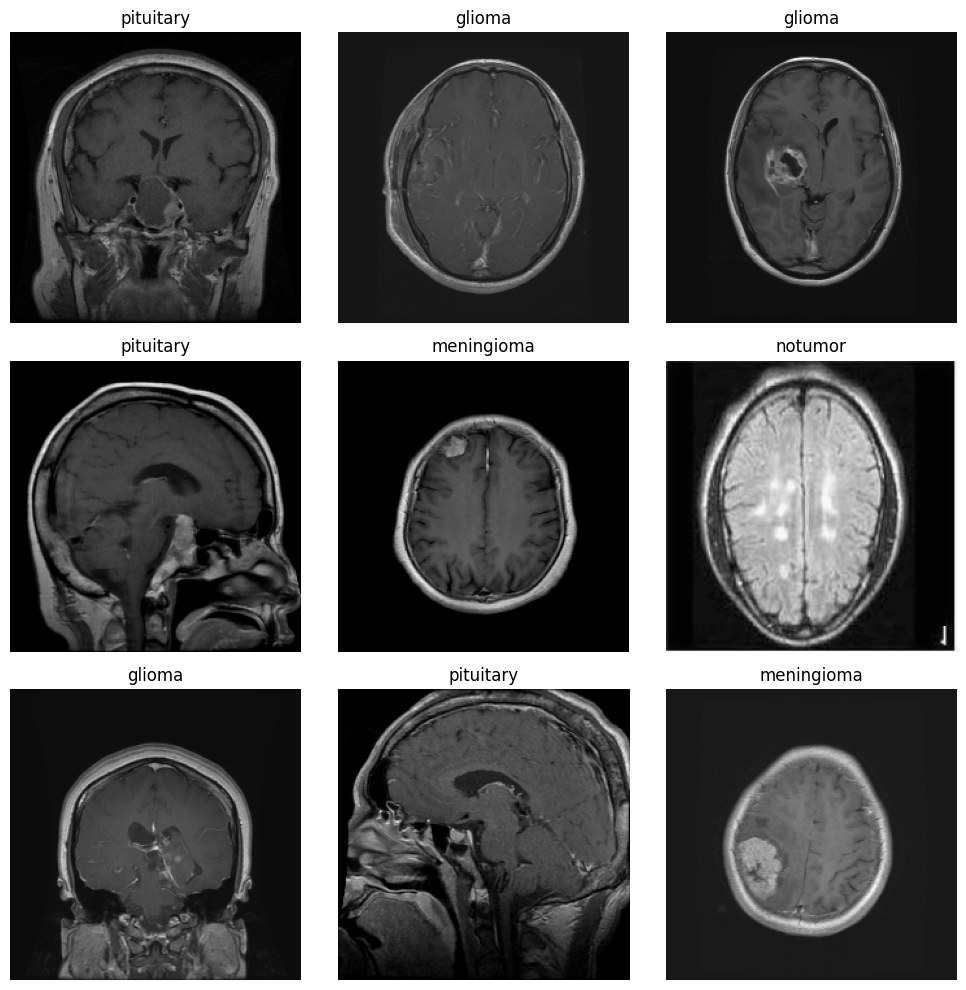

In [4]:
# Grab a batch from the dataset and plot it
images, labels = next(iter(train_ds.take(1)))

# 2. Plot a 3x3 grid
plt.figure(figsize=(10, 10))
for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy())
    plt.title(classes[labels[i]]) #Using the class list from earlier
    plt.axis("off")

plt.tight_layout()
plt.show()

### Define the model

In [ ]:
# Loading Pretrained ResNet50
base_model = tf.keras.applications.ResNet50(input_shape=(224, 224, 3),include_top=False,weights='imagenet')
base_model.trainable = False ### Not training the base model

### Model for classification
inputs = Input(shape=(224, 224, 3)) ## standardize input size (imp for graphs)
x = base_model(inputs, training=False)  ## Add base model as a layer

# Add classification head
x = layers.GlobalAveragePooling2D()(x) ## Using instead of flatten
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(len(classes), activation='softmax')(x)

# Construct the model
model = models.Model(inputs=inputs, outputs=outputs)

# Compile
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Define Callbacks
my_callbacks = [
    callbacks.ModelCheckpoint(filepath='best_resnet_model.keras', monitor='val_accuracy', save_best_only=True),
    callbacks.TensorBoard(log_dir='./logs'),
    callbacks.EarlyStopping(monitor='val_loss', patience=10)
]

start_time=time.time()
# 5. Train
model.fit(train_ds,validation_data=val_ds,epochs=40,callbacks=my_callbacks)
end_time=time.time()
print ("Training time in seconds: ", (end_time-start_time))